In [1]:
# Importation des librairies
import math  # Module de fonctions mathématiques standard de Python
import time

import dolfinx  # Module principal de FEniCSx pour le calcul par éléments finis
import dolfinx.fem as fem  # Module FEniCSx pour la méthode des éléments finis
import dolfinx.mesh as mesh  # Module FEniCSx pour la gestion avancée des maillages
import gmsh  # Générateur de maillage 3D
import ipywidgets as widgets
import matplotlib.pyplot as plt
import meshio  # Lecture/écriture de différents formats de maillage
import numpy as np  # Calcul numérique efficace
import panel as pn
import vtk
import pyvista as pv  # Visualisation 3D scientifique
import ufl  # Unified Form Language pour les formulations variationnelles
from dolfinx import (  # Sous-modules FEniCSx essentiels
    default_scalar_type,
    fem,
    io,
    mesh,
    plot,
)
from dolfinx.fem.petsc import LinearProblem  # Résolution de systèmes linéaires
from dolfinx.io import XDMFFile  # Gestion des fichiers XDMF pour données volumineuses
from IPython.display import clear_output, display
from ipywidgets import HBox, VBox
from mpi4py import MPI  # Interface pour le calcul parallèle
from myst_nb import glue
from petsc4py import (
    PETSc,  # Suite de solveurs numériques pour problèmes à grande échelle
)

In [2]:
# Utiliser Panel pour créer un rendu interactif
pn.extension("vtk")

## Géométrie

### Définition de la géométrie et du maillage

In [3]:
# Initialisation du plotteur PyVista en dehors de la fonction
p = pv.Plotter(notebook=True)
p.set_background("grey")


# Fonction pour créer et visualiser la géométrie
def create_ellipse(rho_x, rho_y, h=0.5, lc=0.01):
    global domain
    gmsh.initialize()
    # gmsh.mash.getInfo()

    gmsh.option.setNumber("General.Terminal", 1)
    gmsh.model.add("ellipse")

    # Création de l'ellipse
    ellipse = gmsh.model.occ.addEllipse(0, 0, 0, rho_x, rho_y)
    curve_loop = gmsh.model.occ.addCurveLoop([ellipse])
    surface = gmsh.model.occ.addPlaneSurface([curve_loop])

    # Extrusion pour obtenir un cylindre elliptique
    gmsh.model.occ.extrude([(2, surface)], 0, 0, h)
    gmsh.model.occ.synchronize()

    # Configuration du maillage
    gmsh.option.setNumber("Mesh.CharacteristicLengthMin", lc)
    gmsh.option.setNumber("Mesh.CharacteristicLengthMax", lc)
    gmsh.model.mesh.generate(3)

    # Sauvegarde et conversion du maillage
    gmsh.write("ellipse.msh")
    msh = meshio.read("ellipse.msh")
    meshio.write(
        "ellipse.xdmf",
        meshio.Mesh(
            points=msh.points, cells={"tetra": msh.cells_dict.get("tetra", [])}
        ),
    )
    gmsh.finalize()

    # Lecture du maillage avec FEniCSx
    with XDMFFile(MPI.COMM_WORLD, "ellipse.xdmf", "r") as xdmf_file:
        domain = xdmf_file.read_mesh(name="Grid")
        domain.topology.create_connectivity(
            domain.topology.dim - 1, domain.topology.dim
        )

    # Conversion du maillage pour la visualisation avec PyVista
    u_topology, u_cell_types, u_geometry = plot.vtk_mesh(domain)
    u_grid = pv.UnstructuredGrid(u_topology, u_cell_types, u_geometry)

    # Effacer la scène précédente et ajouter le nouveau maillage
    p.clear()
    # Ajout du maillage à la scène de visualisation
    p.add_mesh(
        u_grid,
        show_edges=True,  # Affiche les arêtes du maillage
        scalar_bar_args={
            "title": "u",  # Titre de la barre de couleur
            "title_font_size": 24,
            "label_font_size": 22,
            "shadow": True,
            "italic": True,
            "font_family": "arial",
            "vertical": False,  # Orientation horizontale de la barre de couleur
        },
    )

    # Ajout d'un titre à la visualisation
    p.add_text(r"Géométrie&Maillage : Cylindre", font_size=24, color="white", position="upper_edge")

    # Ajout des limites de la boîte englobante
    p.show_bounds(color="white")

    # Ajout des axes de coordonnées
    p.add_axes(color="white")

    # Définition de la couleur de fond
    p.set_background("black")

    # Mise à jour de la scène
    p.show()

    return rho_x, rho_y, h, lc


# Widgets interactifs pour a, b, et h
rho_x_slider = widgets.FloatSlider(
    value=0.1, min=0.01, max=0.2, step=0.01, description="Demi-grand axe"
)
rho_y_slider = widgets.FloatSlider(
    value=0.1, min=0.01, max=0.2, step=0.01, description="Demi-petit axe"
)
h_slider = widgets.FloatSlider(
    value=0.5, min=0.1, max=1.0, step=0.1, description="Hauteur"
)
lc_slider = widgets.FloatSlider(
    value=0.015, min=0.01, max=0.1, step=0.01, description="finesse"
)

# Interface utilisateur et fonction interactive
ui = widgets.VBox([rho_x_slider, rho_y_slider, h_slider, lc_slider])
out = widgets.interactive_output(
    create_ellipse,
    {
        "rho_x": rho_x_slider,
        "rho_y": rho_y_slider,
        "h": h_slider,
        "lc": lc_slider,
    },
)

display(ui, out)


# Fonction pour récupérer les valeurs actuelles des curseurs
def get_slider_values():
    current_rho_x = rho_x_slider.value
    current_rho_y = rho_y_slider.value
    current_h = h_slider.value
    current_lc = lc_slider.value
    return current_rho_x, current_rho_y, current_h, current_lc


# Exemple d'utilisation : récupération des valeurs
rho_x, rho_y, h, lc = get_slider_values()
rho = np.array([rho_x, rho_y])  # Demi-axes dans les directions x et y

Output()

In [4]:
# Utiliser Panel pour créer un rendu interactif
interactive_panel = pn.pane.VTK(p.ren_win, width=755, height=400)
glue("img1", interactive_panel)

VTKRenderWindowSynchronized(vtkCocoaRenderWindow, height=400, sizing_mode='fixed', width=755)

## Configuration du problème

### Définition de l'espace fonctionnel 

In [5]:
# Définition de l'espace fonctionnel pour le problèmeFiniteElementV = fem.
# V = fem.functionspace(domain, ("CG", 2))

V = fem.functionspace(domain, ("CG", 2, (domain.geometry.dim,)))
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

### Définition des frontière du domaine 

In [6]:
# Définition des fonctions pour identifier les différentes faces du cylindre
def down_face(x):
    """Identifie la face inférieure du cylindre (z = 0)"""
    return np.isclose(x[2], 0)


def top_face(x):
    """Identifie la face supérieure du cylindre (z = h)"""
    return np.isclose(x[2], h)


def lateral_face(x):
    """
    Identifie la surface latérale du cylindre elliptique
    Utilise l'équation de l'ellipse : x^2/a^2 + y^2/b^2 = 1
    """
    tolerance = 1e-5  # Tolérance pour la comparaison numérique
    return (
        (
            np.isclose(
                (x[0] ** 2 / rho[0] ** 2 + x[1] ** 2 / rho[1] ** 2), 1.0, atol=tolerance
            )
        )
        & (0 <= x[2])
        & (x[2] <= h)
    )


# Dimension des facettes (2D pour un domaine 3D)
fdim = domain.topology.dim - 1

# Localisation des entités (facettes) correspondant à chaque face
Sigma_l = mesh.locate_entities(domain, fdim, lateral_face)
Sigma_0 = mesh.locate_entities(domain, fdim, down_face)
Sigma_h = mesh.locate_entities(domain, fdim, top_face)

# Préparation des marqueurs de facettes pour les conditions aux limites
marked_facets = np.hstack([Sigma_l, Sigma_0, Sigma_h])
marked_values = np.hstack(
    [
        np.full_like(Sigma_l, 1),  # Marqueur 1 pour la face latérale
        np.full_like(Sigma_0, 2),  # Marqueur 2 pour la face inférieure
        np.full_like(Sigma_h, 3),  # Marqueur 3 pour la face supérieure
    ]
)

# Tri et création des tags de maillage
sorted_indices = np.argsort(marked_facets)
facet_tag = dolfinx.mesh.meshtags(
    domain, fdim, marked_facets[sorted_indices], marked_values[sorted_indices]
)

# Définition de la mesure pour les facettes marquées
ds = ufl.Measure("ds", domain=domain, subdomain_data=facet_tag)


# Création d'un dictionnaire pour mapper les noms aux valeurs numériques
surface_ids = {"Sl": 1, "S0": 2, "Sh": 3}

### Visualisation des frontière du domaine

In [7]:
# Définition d'une fonction pour appliquer des marqueurs aux facettes
def apply_marker(boundary_facets, marker_array, marker_value):
    """
    Applique un marqueur spécifique aux facettes de la frontière.

    Args:
    boundary_facets: Indices des facettes de la frontière
    marker_array: Tableau des marqueurs à mettre à jour
    marker_value: Valeur du marqueur à appliquer
    """
    # Filtrer les facettes pour ne garder que celles appartenant au domaine local
    boundary_facets = boundary_facets[boundary_facets < num_cells_local]
    # Appliquer le marqueur
    marker_array[boundary_facets] = marker_value


# Obtenir le nombre de cellules locales (important pour le calcul parallèle)
num_cells_local = domain.topology.index_map(fdim).size_local

# Initialiser les tableaux de marqueurs pour chaque type de frontière
# On crée 4 tableaux : 3 pour chaque face et 1 pour la combinaison
markers = [np.zeros(num_cells_local, dtype=np.int32) for _ in range(4)]

# Appliquer les marqueurs spécifiques à chaque face
apply_marker(Sigma_0, markers[0], 1)  # Face inférieure (z = 0)
apply_marker(Sigma_h, markers[1], 2)  # Face supérieure (z = h)
apply_marker(Sigma_l, markers[2], 3)  # Surface latérale

# Calculer le marqueur combiné
markers[3] = markers[0] + markers[1] + markers[2]

# Ajouter un marqueur spécifique (4) pour les cellules non marquées
# Cela peut être utile pour identifier le volume intérieur, par exemple
markers[3][markers[3] == 0] = 4

# Créer la connectivité topologique pour les facettes
# Ceci est nécessaire pour certaines opérations sur le maillage
domain.topology.create_connectivity(fdim, fdim)

# Obtenir les données de maillage au format compatible avec PyVista
topology, cell_types, x = dolfinx.plot.vtk_mesh(
    domain, fdim, np.arange(num_cells_local, dtype=np.int32)
)

In [8]:
# Création du maillage PyVista à partir des données FEniCSx
grid = pv.UnstructuredGrid(topology, cell_types, x)


def add_plot(ax, marker, color, title, threshold_min):
    """
    Fonction pour ajouter des maillages à une sous-fenêtre de visualisation.

    Args:
    ax: Axe de la sous-fenêtre PyVista
    marker: Tableau des marqueurs pour les cellules
    color: Couleur pour les cellules filtrées
    title: Titre de la sous-fenêtre
    threshold_min: Valeur minimale pour le filtrage des cellules
    """
    # Mise à jour des données de cellule du maillage avec les marqueurs
    grid.cell_data["Marker"] = marker
    grid.set_active_scalars("Marker")

    # Ajout du maillage complet avec les marqueurs
    ax.add_mesh(
        grid,
        show_edges=True,
        color="cyan",
        scalar_bar_args={
            "title": "Boundary Marker",
            "title_font_size": 24,
            "label_font_size": 22,
            "shadow": True,
            "italic": True,
            "font_family": "arial",
            "vertical": False,
        },
    )

    # Application d'un filtre basé sur le seuil pour isoler certaines cellules
    grid_filter = grid.threshold(threshold_min, scalars="Marker")
    ax.add_mesh(grid_filter, color=color, show_edges=True)

    # Ajout du titre et des axes à la sous-fenêtre
    ax.add_text(title, font_size=12, color="black", position="upper_edge")
    ax.add_axes(color="black")


# Configuration de la visualisation PyVista avec 4 sous-fenêtres (2x2)
pl = pv.Plotter(shape=(2, 2))

# Sous-fenêtre 1 : Affichage de toutes les frontières
pl.subplot(0, 0)
add_plot(pl, markers[3], "red", "All Boundaries", threshold_min=0.5)
pl.camera_position = [
    (1, 1, 1),
    (0, 0, 0.3),
    (0, 0, 0.5),
]  # Vue isométrique pour subplot 1

# Sous-fenêtre 2 : Affichage de la frontière inférieure
pl.subplot(0, 1)
add_plot(pl, markers[0], "red", "Down Boundary", threshold_min=0.5)
pl.camera_position = [
    (1, 1, 1),
    (0, 0, 0.3),
    (0, 0, 0.5),
]  # Vue isométrique pour subplot 2

# Sous-fenêtre 3 : Affichage de la frontière supérieure
pl.subplot(1, 0)
add_plot(pl, markers[1], "red", "Top Boundary", threshold_min=1.5)
pl.camera_position = [
    (1, 1, 1),
    (0, 0, 0.3),
    (0, 0, 0.5),
]  # Vue isométrique pour subplot 3

# Sous-fenêtre 4 : Affichage de la frontière latérale
pl.subplot(1, 1)
add_plot(pl, markers[2], "red", "Lateral Boundary", threshold_min=2.5)
pl.camera_position = [
    (1, 1, 1),
    (0, 0, 0.3),
    (0, 0, 0.5),
]  # Vue isométrique pour subplot 4

# Configuration finale et affichage
pl.set_background("grey")

pl.show()

Widget(value='<iframe src="http://localhost:50705/index.html?ui=P_0x166ccafc0_1&reconnect=auto" class="pyvista…

In [9]:
pl.camera_position = [
    (1, 1, 1),  # Position de la caméra (x, y, z)
    (0, 0, 0.3),  # Point ciblé (centre de la scène)
    (0, 0, 0.5),  # Orientation de la caméra (vers le haut)
]
# Utiliser Panel pour créer un rendu interactif
interactive_panel = pn.pane.VTK(pl.ren_win, width=755, height=400)
glue("img2", interactive_panel)

VTKRenderWindowSynchronized(vtkCocoaRenderWindow, height=400, sizing_mode='fixed', width=755)

## Conditions aux limites

In [10]:
# Définition des conditions aux limites de Dirichlet (déplacement nul)
u_D = np.array([0, 0, 0], dtype=default_scalar_type)

# Application des conditions aux limites sur chaque face
bc0_S0 = fem.dirichletbc(
    u_D, fem.locate_dofs_topological(V, fdim, Sigma_0), V
)  # Face inférieure
bc0_Sh = fem.dirichletbc(
    u_D, fem.locate_dofs_topological(V, fdim, Sigma_h), V
)  # Face supérieure
bc0_Sl = fem.dirichletbc(
    u_D, fem.locate_dofs_topological(V, fdim, Sigma_l), V
)  # Surface latérale

## Propriétés matériau

In [11]:
def calculate_lame_constants(E, nu):
    """
    Calcule les coefficients de Lamé (mu et lambda) à partir de E et nu.

    Args:
        E (float): Module de Young (Pa).
        nu (float): Coefficient de Poisson (sans unité).

    Returns:
        tuple: (mu, lambda) en Pascals.
    """
    mu = E / (2 * (1 + nu))
    lambda_ = (E * nu) / ((1 + nu) * (1 - 2 * nu))
    return mu, lambda_


# Exemple d'utilisation
E = 210e9  # 210 GPa en Pascals
nu = 0.3  # Coefficient de Poisson
mu, lambda_ = calculate_lame_constants(E, nu)

# mu=
# lambda_=

# Widgets pour les constantes élastiques en GPa
mu_input = widgets.FloatText(value=mu, description="μ = ", step=1)
mu_label = widgets.Label(value="Pa")

lambda_input = widgets.FloatText(value=lambda_, description="λ = ", step=1)
lambda_label = widgets.Label(value="Pa")

# Organisation avec les labels d'unité
mu_box = HBox([mu_input, mu_label])
lambda_box = HBox([lambda_input, lambda_label])


# Fonction pour obtenir les constantes élastiques en Pa
def display_elastic_constants(change):
    mu = mu_input.value  # Conversion en Pa
    lambda_ = lambda_input.value  # Conversion en Pa

    # Afficher les valeurs en Pa
    clear_output(wait=True)  # Clear previous output

    return mu, lambda_  # Retourner les valeurs en Pa


# Liaison de la fonction d'affichage aux événements de changement de valeur des widgets
mu_input.observe(display_elastic_constants, names="value")
lambda_input.observe(display_elastic_constants, names="value")

# Affichage des widgets
ui_elastic = VBox([mu_box, lambda_box])
display(ui_elastic)

In [12]:
mu, lambda_ = display_elastic_constants("value")
# Formater pour afficher en GPa
print(f"Module de cisaillement (μ) = {mu / 1e9:.2f} GPa")
print(f"Premier paramètre de Lamé (λ) = {lambda_ / 1e9:.2f} GPa")

Module de cisaillement (μ) = 80.77 GPa
Premier paramètre de Lamé (λ) = 121.15 GPa


## Définition des chargements

In [13]:
# Définition des composantes du champ de torsion (vecteur des Contraintes de Cauchy)
T1 = ufl.as_ufl(
    0.0
)  # Composante x du champ de torsion / Contrainte de cisaillement dans la direction x
T2 = ufl.as_ufl(
    0.0
)  # Composante y du champ de torsion / Contrainte de cisaillement dans la direction y
T3 = ufl.as_ufl(
    0.0
)  # Composante z nulle / Pas de contrainte dans la direction z (axe de torsion)

# Combinaison en un champ vectoriel de torsion
T = ufl.as_vector([T1, T2, T3])
print(
    f"Vecteur de contrainte de Cauchy défini pour la torsion (N/m²); T = ({T1},{T2},{T3}) GPa "
)


def calculate_force_volumique(rho, g=9.81):
    """
    Calcule la force volumique f à partir de la masse volumique rho et de l'accélération gravitationnelle g.

    Args:
        rho (float): Masse volumique en kg/m^3.
        g (float): Accélération gravitationnelle en m/s^2 (par défaut 9.81).

    Returns:
        float: Force volumique f en N/m^3.
    """
    return rho * g


# Exemple d'utilisation
rhov = 7850  # Masse volumique de l'acier en kg/m^3
g = 9.81  # Accélération gravitationnelle en m/s^2
fv = calculate_force_volumique(rhov, g)

# Définition de la force volumique (nulle dans ce cas)
f = fem.Constant(domain, default_scalar_type((0, 0, -fv)))

Vecteur de contrainte de Cauchy défini pour la torsion (N/m²); T = (0,0,0) GPa 


In [14]:
# Définition des tenseurs de déformation et de contrainte
def epsilon(u):
    """Tenseur de déformation linéarisé"""
    return ufl.sym(ufl.grad(u))


def sigma(u):
    """Tenseur des contraintes (loi de Hooke)"""
    return lambda_ * ufl.nabla_div(u) * ufl.Identity(len(u)) + 2 * mu * epsilon(u)


# Définition des fonctions d'essai et de test
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)


# Formulation variationnelle du problème
a = ufl.inner(sigma(u), epsilon(v)) * ufl.dx  # Forme bilinéaire

# Créez un widget Dropdown
surface_selector = widgets.Dropdown(
    options=[
        ("Surface latérale Sl", "Sl"),
        ("Surface inférieure S0", "S0"),
        ("Surface supérieure Sh", "Sh"),
    ],
    value="Sh",
    description="Surface:",
    disabled=False,
)

# Créez un widget de sortie pour afficher les messages
output = widgets.Output()


# Fonction pour mettre à jour la forme linéaire
def update_linear_form(change):
    global L
    selected_surface = change["new"]
    # Mise à jour de la forme linéaire
    L = ufl.dot(f, v) * ufl.dx
    # Mise à jour de l'affichage
    with output:
        output.clear_output(wait=True)
        print(f"Torsion appliquée sur {selected_surface}")


# Attacher la fonction de mise à jour au widget
surface_selector.observe(update_linear_form, names="value")

# Afficher le widget et la sortie
display(widgets.VBox([surface_selector, output]))

# Initialiser l'affichage
update_linear_form({"new": surface_selector.value})

## Résolution

In [15]:
# Créez un widget Dropdown pour la sélection de la condition aux limites
bc_selector = widgets.Dropdown(
    options=[
        ("Aucune", "none"),
        ("Face inférieure S0", "S0"),
        ("Face supérieure Sh", "Sh"),
        ("Surface latérale Sl", "Sl"),
    ],
    value="S0",  # Valeur par défaut
    description="Encastrement:",
    disabled=False,
)

# Dictionnaire pour mapper les sélections aux conditions aux limites
bc_dict = {"none": [], "S0": [bc0_S0], "Sh": [bc0_Sh], "Sl": [bc0_Sl]}

# Créez un widget de sortie pour afficher les messages
output = widgets.Output()


# Fonction pour mettre à jour le problème
def update_problem(change):
    global problem
    selected_bc = change["new"]
    problem = LinearProblem(
        a,
        L,
        bcs=bc_dict[selected_bc],
        petsc_options={"ksp_type": "cg", "pc_type": "jacobi"},
    )

    # Mise à jour de l'affichage
    with output:
        output.clear_output(wait=True)
        print(f"Encastrement appliquée sur {selected_bc}")


# Attacher la fonction de mise à jour au widget
bc_selector.observe(update_problem, names="value")

# Afficher le widget
display(bc_selector, output)

# Initialisation du problème avec la valeur par défaut
update_problem({"new": bc_selector.value})

# Avant la résolution
start_time = time.time()

# Résolution du problème EF
uh = problem.solve()

# Après la résolution
end_time = time.time()

# Temps de calcul
elapsed_time = end_time - start_time
print(f"Temps de calcul pour la résolution : {elapsed_time:.4f} secondes")

Dropdown(description='Encastrement:', index=1, options=(('Aucune', 'none'), ('Face inférieure S0', 'S0'), ('Fa…

Output()

Temps de calcul pour la résolution : 3.2358 secondes


### Visualisation des déplacements

In [16]:
# Création du maillage pour PyVista basé sur les coordonnées des dofs
u_topology, u_cell_types, u_geometry = plot.vtk_mesh(V)

# Créez la grille PyVista et ajoutez les valeurs des dofs à la grille
u_grid = pv.UnstructuredGrid(u_topology, u_cell_types, u_geometry)

# Attachement des valeurs de déplacement DOFs
uz_values = uh.x.array[2::3]  # Composante z uniquement
num_geometry_nodes = u_geometry.shape[0]
dofs = uh.x.array.reshape(
    -1, domain.geometry.dim
)  # Reshape DOFs par rapport à la dimension
u_grid["u"] = dofs[
    : u_geometry.shape[0]
]  # Ajuster les DOFs pour qu'ils correspondent aux nœuds géométriques

# Attach vector values to grid
# u_grid["u"] = uh.x.array.reshape((u_geometry.shape[0], 3))
u_x = dofs[:num_geometry_nodes, 0]
u_y = dofs[:num_geometry_nodes, 1]
u_z = dofs[:num_geometry_nodes, 2]
# Ajout des composantes au maillage PyVista
u_grid["u_x"] = u_x
u_grid["u_y"] = u_y
u_grid["u_z"] = u_z

# Calcul correct de la magnitude des déplacements
# u_magnitude = np.linalg.norm(u_grid["u"], axis=1)  # Norme des déplacements vectoriels
# u_grid["u_m"] = u_magnitude

u_grid_warped = u_grid.warp_by_vector("u", factor=1000000)

min(u_z)

np.float64(-4.5178546550282906e-08)

In [17]:
mathtext = vtk.vtkMatplotlibMathTextUtilities.GetInstance()
if mathtext is not None:
    print("MathText is supported")
else:
    print("MathText is not supported")

MathText is supported


In [18]:
# Détection des nœuds situés à la base supérieure (z ≈ H)
tol = 1e-6  # Tolérance numérique
top_nodes = np.abs(u_geometry[:, 2] - h) < tol  # Filtre les nœuds avec z ≈ H

# Création du sous-maillage contenant uniquement la base supérieure
u_grid_top = u_grid.extract_points(top_nodes)

# Création d'un maillage déformé pour exagérer les déplacements
u_grid_top_warped = u_grid_top.warp_by_vector("u", factor=100e6)

# Visualisation avec PyVista
p = pv.Plotter()

# Ajout du maillage filtré
p.add_mesh(
    u_grid_top_warped,
    show_edges=False,
    scalars="u_z",  # Coloration en fonction de la composante uz
    cmap="plasma",  # Changer la colormap
    scalar_bar_args={
        "title": "$u_z$",
        "title_font_size": 24,
        "label_font_size": 22,
        "shadow": False,
        "italic": True,
        "color": "white",
        "font_family": "arial",
        "vertical": False,
    },
)

# Configuration de la scène
p.add_text(r'Surface $\Gamma_1$', font_size=12, color="white", position="upper_edge")
p.add_axes(color="white")
p.show_bounds(color="white")
p.set_background("black")

# Zoom caméra sur la base supérieure
p.camera_position = [
    (0.2, 0.2, 0.6),  # Position éloignée de la caméra
    (0, 0, h + 0.5),  # Point ciblé (centre de la base supérieure)
    (0, 0, 1),  # Orientation vers le haut
]

# Affichage
p.show()

Widget(value='<iframe src="http://localhost:50705/index.html?ui=P_0x2852a2cc0_2&reconnect=auto" class="pyvista…

In [19]:
# Visualisation
p = pv.Plotter()
p.add_mesh(
    u_grid_warped,
    show_edges=False,
    scalars="u_z",
    scalar_bar_args={
        "title": "$u_z$",
        "title_font_size": 24,
        "label_font_size": 22,
        "shadow": False,
        "italic": True,
        "color": "white",
        "font_family": "arial",
        "vertical": False,
    },
)
p.add_text("Déplacements", font_size=12, color="white", position="upper_edge")
p.add_axes(color="white")
p.set_background("black")
p.camera_position = [
    (1, 1, 1),  # Position de la caméra (x, y, z)
    (0, 0, 0.3),  # Point ciblé (centre de la scène)
    (0, 0, 0.5),  # Orientation de la caméra (vers le haut)’
]

p.show()

Widget(value='<iframe src="http://localhost:50705/index.html?ui=P_0x28d7c4fe0_3&reconnect=auto" class="pyvista…

In [20]:
# Utiliser Panel pour créer un rendu interactif
interactive_panel = pn.pane.VTK(p.ren_win, width=755, height=400)
glue("img3", interactive_panel)

VTKRenderWindowSynchronized(vtkCocoaRenderWindow, color_mappers=[LinearColorMapper(id='0eb...], height=400, sizing_mode='fixed', width=755)

In [21]:
# Définition des arguments communs pour l'affichage des maillages
dargs = dict(
    scalars="u",  # Utilise le champ de déplacement 'u' pour la coloration
    cmap="jet",  # Utilise la palette de couleurs 'jet'
    show_scalar_bar=False,  # Ne pas afficher la barre de couleur pour chaque sous-plot
)

# Création d'un plotter PyVista avec une grille 2x2 de sous-plots
pl = pv.Plotter(shape=(2, 2))

# Sous-plot 0,0 : Déplacement normalisé (magnitude)
pl.subplot(0, 0)
pl.add_mesh(u_grid, **dargs)
pl.add_axes(color="black")
pl.add_text("Normalized Displacement", color="k", font_size=10)

# Sous-plot 0,1 : Déplacement selon X
pl.subplot(0, 1)
pl.add_mesh(u_grid.copy(), component=0, **dargs)
pl.add_axes(color="black")
pl.add_text("X Displacement", color="k", font_size=10)

# Sous-plot 1,0 : Déplacement selon Y
pl.subplot(1, 0)
pl.add_mesh(u_grid.copy(), component=1, **dargs)
pl.add_axes(color="black")
pl.add_text("Y Displacement", color="k", font_size=10)

# Sous-plot 1,1 : Déplacement selon Z
pl.subplot(1, 1)
pl.add_mesh(u_grid.copy(), component=2, **dargs)
pl.add_axes(color="black")
pl.add_text("Z Displacement", color="k", font_size=10)

# Configuration globale de la visualisation
pl.link_views()  # Lie les vues des sous-plots pour une navigation synchronisée
pl.camera_position = "iso"  # Vue isométrique
pl.background_color = "grey"  # Couleur de fond grise

# Ajout d'une barre de couleur globale
pl.add_scalar_bar(
    title="Displacement (m)",
    n_labels=5,
    label_font_size=10,
    title_font_size=12,
    position_x=0.25,
    position_y=0.05,
    width=0.5,
)

# Affichage de la visualisation
pl.show()

Widget(value='<iframe src="http://localhost:50705/index.html?ui=P_0x29b5b1ac0_4&reconnect=auto" class="pyvista…

### Visualisation des contraintes de von Mises 

In [22]:
s = sigma(uh) - 1.0 / 3 * ufl.tr(sigma(uh)) * ufl.Identity(len(uh))
von_Mises = ufl.sqrt(3.0 / 2 * ufl.inner(s, s))

V_von_mises = fem.functionspace(domain, ("DG", 0))
stress_expr = fem.Expression(von_Mises, V_von_mises.element.interpolation_points())
stresses = fem.Function(V_von_mises)
stresses.interpolate(stress_expr)

# Créez une nouvelle instance de Plotter
# Ajout des données de contrainte de von Mises au maillage déformé
warped = u_grid.warp_by_vector(
    "u", factor=0
)  # Pas de déformation pour visualiser les déformations
warped.cell_data["VonMises"] = stresses.vector.array
# Définition de "VonMises" comme scalaire actif pour la visualisation
warped.set_active_scalars("VonMises")

# Création d'une nouvelle instance de Plotter PyVista
p = pv.Plotter()

# Ajout du maillage déformé avec la contrainte de von Mises
p.add_mesh(
    warped,
    cmap="jet",  # Utilisation de la carte de couleurs "jet"
    show_edges=False,  # Ne pas afficher les arêtes du maillage
    scalar_bar_args={
        "title": "von Mises (MPa)",  # Titre de la barre de couleur
        "title_font_size": 24,  # Taille de la police du titre
        "label_font_size": 22,  # Taille de la police des étiquettes
        "shadow": True,  # Ajout d'une ombre à la barre de couleur
        "italic": True,  # Texte en italique
        "font_family": "arial",  # Police Arial
        "vertical": False,  # Barre de couleur horizontale
    },
)

# Ajout d'un titre à la visualisation
p.add_text(
    "Contraintes de von Mises", font_size=12, color="black", position="upper_edge"
)

# Ajout des axes de coordonnées en noir
p.add_axes(color="black")

# Configuration de l'arrière-plan en gris
p.set_background("grey")

# Configuration de la caméra pour une vue optimale
# p.camera_position = [(3, 3, 2), (0, 0, 0.5), (0, 0, 1)]

# Affichage de la visualisation
p.camera_position = [
    (1, 1, 1),  # Position de la caméra (x, y, z)
    (0, 0, 0.3),  # Point ciblé (centre de la scène)
    (0, 0, 0.5),  # Orientation de la caméra (vers le haut)
]
p.show()

Widget(value='<iframe src="http://localhost:50705/index.html?ui=P_0x29b5b1580_5&reconnect=auto" class="pyvista…

In [23]:
# Utiliser Panel pour créer un rendu interactif
interactive_panel = pn.pane.VTK(p.ren_win, width=755, height=400)
glue("img4", interactive_panel)
pn.extension("vtk")

VTKRenderWindowSynchronized(vtkCocoaRenderWindow, color_mappers=[LinearColorMapper(id='f64...], height=400, sizing_mode='fixed', width=755)

## Post-traitements

In [24]:
# Données d'entrée
u_z_theorique = -4.581e-08 # u_z0 calculé dans le chapitre 1.

uz_center_0 = -4.516876e-08  # lc = 0.1 ; 128 élements
uz_center_1 = -4.508939e-08  # lc = 0.05 ; 785 élements
uz_center_2 = -4.511100e-08  # lc = 0.04 ; 1406 élements
uz_center_3 = -4.514429e-08  # lc = 0.03 ; 3102 élements
uz_center_4 = -4.516689e-08  # lc = 0.02 ; 10017 élements
uz_center_5 = -4.518891e-08  # lc = 0.01 ; 73586 élements

u_z_ef = [
    uz_center_0,
    uz_center_1,
    uz_center_2,
    uz_center_3,
    uz_center_4,
    uz_center_5,
]  # Déplacements EF pour différents maillages

# Calcul des erreurs relatives pour chaque maillage
erreurs_relatives = [abs(u_z_theorique - u) / abs(u_z_theorique) * 100 for u in u_z_ef]

# Affichage des résultats
erreurs_relatives

[1.3997817070508536,
 1.5730408207814854,
 1.5258677144728192,
 1.45319799170487,
 1.4038637851997307,
 1.3557956777996034]

### Comparaison Analytique-Numérique


| Maillage (nombre d'éléments) | \(u_z(O')\) (théorique) [nm] | \(u_z(O')\) (EF) [nm] | Erreur relative (%) |
|------------------------------|------------------------------|-----------------------|----------------------|
| 128 (Grossier)            | -0.458                       | -4.516876                | 1.40                 |
| 785                       | -0.458                       | -4.508939                | 1.57                 |
| 1406                      | -0.458                       | -4.511100                | 1.53                 |
| 3102                      | -0.458                       | -4.514429                | 1.45                 |
| 10017                     | -0.458                       | -4.516689                | 1.40                 |
| 73586 (fin)               | -0.458                       | -4.518891                | 1.36                 |

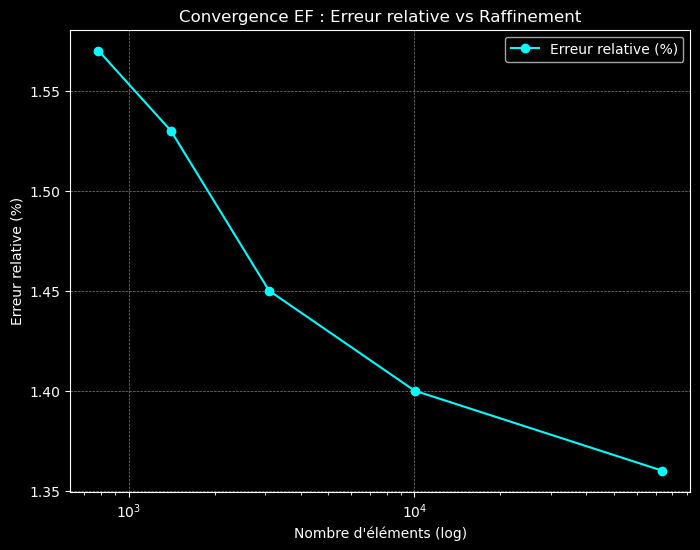

In [25]:
import matplotlib.pyplot as plt

# Créer un style sombre personnalisé
plt.style.use("dark_background")

# Données d'exemple
elements = [785, 1406, 3102, 10017, 73586]
errors = [1.57, 1.53, 1.45, 1.40, 1.36]

# Appliquer le thème sombre
plt.figure(figsize=(8, 6))
plt.plot(elements, errors, marker="o", color="cyan", label="Erreur relative (%)")
plt.xscale("log")
plt.xlabel("Nombre d'éléments (log)")
plt.ylabel("Erreur relative (%)")
plt.title("Convergence EF : Erreur relative vs Raffinement")

plt.legend()
plt.grid(color="grey", linestyle="--", linewidth=0.5)
plt.show()